# Final Project: League of Legends Match Predictor


### Introduction  

League of Legends, a popular multiplayer online battle arena (MOBA) game, generates extensive data from matches, providing an excellent opportunity to apply machine learning techniques to real-world scenarios. Perform the following steps to build a logistic regression model aimed at predicting the outcomes of League of Legends matches.  

Use the `league_of_legends_data_large.csv` file to perform the tasks.  


### Setup
Installing required libraries:


In [1]:
%%time
%pip install pandas scikit-learn matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu


Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
CPU times: user 65 ms, sys: 26.8 ms, total: 91.8 ms
Wall time: 3.53 s


---
## Step 1: Data Loading and Preprocessing
### Exercise 1 — Load, split, scale, and convert to PyTorch tensors


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
data = pd.read_csv('league_of_legends_data_large.csv')
print("Dataset shape:", data.shape)
print(data.head())

# 2. Split into features (X) and target (y)
X = data.drop('win', axis=1)
y = data['win']

# 3. Train / test split  (80 % train, 20 % test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 5. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,  dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test.values,   dtype=torch.float32).unsqueeze(1)

print("\nTraining set size :", X_train_tensor.shape)
print("Test set size     :", X_test_tensor.shape)


Dataset shape: (1000, 9)
   win  kills  deaths  assists  gold_earned   cs  wards_placed  wards_killed  \
0    0     16       6       19        17088  231            11             7   
1    1      8       8        5        14865  259            10             2   
2    0      0      17       11        15919  169            14             5   
3    0     19      11        1        11534  264            14             3   
4    0     12       7        6        18926  124            15             7   

   damage_dealt  
0         15367  
1         38332  
2         24642  
3         15789  
4         40268  

Training set size : torch.Size([800, 8])
Test set size     : torch.Size([200, 8])


---
## Step 2: Logistic Regression Model
### Exercise 2 — Define the model, loss function, and optimiser


In [3]:
# 1. Define the logistic regression model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)   # single output unit

    def forward(self, x):
        return torch.sigmoid(self.linear(x))    # sigmoid -> probability in [0, 1]

# 2. Initialise model, loss function, and optimiser
input_dim = X_train_tensor.shape[1]             # number of features
model     = LogisticRegressionModel(input_dim)

criterion = nn.BCELoss()                        # Binary Cross-Entropy
optimizer = optim.SGD(model.parameters(), lr=0.01)

print(model)
print(f"\nInput features : {input_dim}")


LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

Input features : 8


---
## Step 3: Model Training
### Exercise 3 — Training loop + accuracy evaluation


In [4]:
# 1. Number of epochs
num_epochs = 1000

# 2. Training loop
for epoch in range(1, num_epochs + 1):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_tensor)             # forward pass
    loss    = criterion(outputs, y_train_tensor) # compute loss

    loss.backward()                             # backpropagation
    optimizer.step()                            # update weights

    # 3. Print every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch [{epoch:4d}/{num_epochs}]  Loss: {loss.item():.4f}")

# 4 & 5. Evaluate on train and test sets
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_test  = model(X_test_tensor)

    train_preds = (y_pred_train >= 0.5).float()
    test_preds  = (y_pred_test  >= 0.5).float()

    train_acc = (train_preds == y_train_tensor).float().mean().item()
    test_acc  = (test_preds  == y_test_tensor ).float().mean().item()

# 6. Print accuracies
print(f"\nTraining Accuracy : {train_acc * 100:.2f}%")
print(f"Test Accuracy     : {test_acc  * 100:.2f}%")


Epoch [ 100/1000]  Loss: 0.7050
Epoch [ 200/1000]  Loss: 0.6978
Epoch [ 300/1000]  Loss: 0.6931
Epoch [ 400/1000]  Loss: 0.6902
Epoch [ 500/1000]  Loss: 0.6884
Epoch [ 600/1000]  Loss: 0.6872
Epoch [ 700/1000]  Loss: 0.6865
Epoch [ 800/1000]  Loss: 0.6860
Epoch [ 900/1000]  Loss: 0.6857
Epoch [1000/1000]  Loss: 0.6855

Training Accuracy : 55.62%
Test Accuracy     : 51.00%


---
## Step 4: Model Optimisation with L2 Regularisation
### Exercise 4 — Retrain with weight decay (Ridge / L2)


In [5]:
# Re-initialise the model so we start fresh
model_l2     = LogisticRegressionModel(input_dim)
criterion_l2 = nn.BCELoss()

# 1. Optimiser with L2 regularisation via weight_decay
optimizer_l2 = optim.SGD(model_l2.parameters(), lr=0.01, weight_decay=0.01)

# 2. Training loop (same structure, 1000 epochs)
num_epochs = 1000
for epoch in range(1, num_epochs + 1):
    model_l2.train()
    optimizer_l2.zero_grad()

    outputs_l2 = model_l2(X_train_tensor)
    loss_l2    = criterion_l2(outputs_l2, y_train_tensor)

    loss_l2.backward()
    optimizer_l2.step()

    if epoch % 100 == 0:
        print(f"Epoch [{epoch:4d}/{num_epochs}]  Loss (L2): {loss_l2.item():.4f}")

# 3 & 4. Evaluate the optimised model
model_l2.eval()
with torch.no_grad():
    y_pred_train_l2 = model_l2(X_train_tensor)
    y_pred_test_l2  = model_l2(X_test_tensor)

    train_acc_l2 = ((y_pred_train_l2 >= 0.5).float() == y_train_tensor).float().mean().item()
    test_acc_l2  = ((y_pred_test_l2  >= 0.5).float() == y_test_tensor ).float().mean().item()

print(f"\n[L2 Regularised] Training Accuracy : {train_acc_l2 * 100:.2f}%")
print(f"[L2 Regularised] Test Accuracy     : {test_acc_l2  * 100:.2f}%")


Epoch [ 100/1000]  Loss (L2): 0.7129
Epoch [ 200/1000]  Loss (L2): 0.7022
Epoch [ 300/1000]  Loss (L2): 0.6956
Epoch [ 400/1000]  Loss (L2): 0.6915
Epoch [ 500/1000]  Loss (L2): 0.6891
Epoch [ 600/1000]  Loss (L2): 0.6876
Epoch [ 700/1000]  Loss (L2): 0.6867
Epoch [ 800/1000]  Loss (L2): 0.6861
Epoch [ 900/1000]  Loss (L2): 0.6858
Epoch [1000/1000]  Loss (L2): 0.6856

[L2 Regularised] Training Accuracy : 54.50%
[L2 Regularised] Test Accuracy     : 50.50%


---
## Step 5: Visualisation and Interpretation
### Exercise 5 — Confusion matrix, ROC curve, classification report


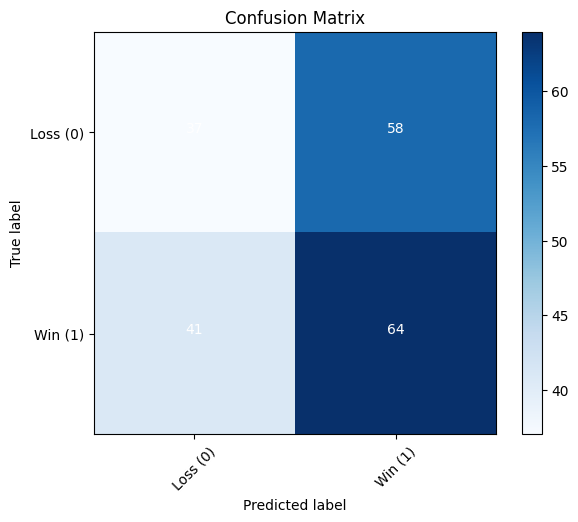

Classification Report:
              precision    recall  f1-score   support

        Loss       0.47      0.39      0.43        95
         Win       0.52      0.61      0.56       105

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.51      0.50       200



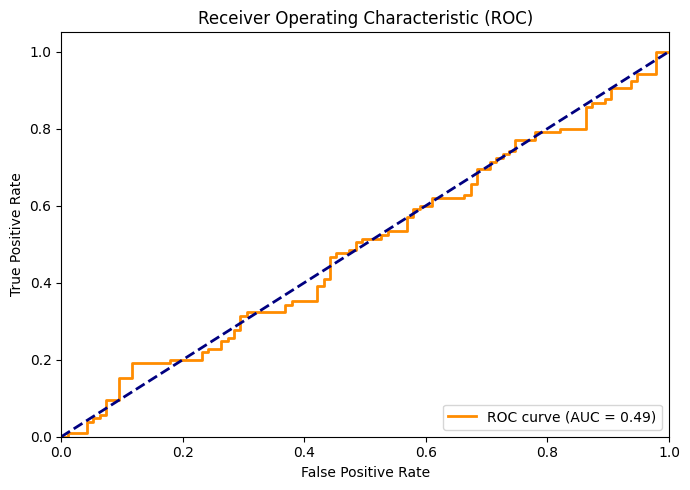

In [6]:
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Use the L2-regularised model predictions on the test set
y_pred_test_labels = (y_pred_test_l2 >= 0.5).float().numpy()
y_pred_test_proba  = y_pred_test_l2.numpy()          # raw probabilities for ROC
y_true             = y_test_tensor.numpy()

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred_test_labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(2)
plt.xticks(tick_marks, ['Loss (0)', 'Win (1)'], rotation=45)
plt.yticks(tick_marks, ['Loss (0)', 'Win (1)'])

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ── Classification Report ─────────────────────────────────────────────────────
print("Classification Report:")
print(classification_report(y_true, y_pred_test_labels, target_names=['Loss', 'Win']))

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_pred_test_proba)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


---
## Step 6: Model Saving and Loading
### Exercise 6 — Persist the model with `torch.save` / `torch.load`


In [7]:
MODEL_PATH = 'lol_logistic_model.pth'

# Save the model's state dictionary (weights & biases only)
torch.save(model_l2.state_dict(), MODEL_PATH)
print(f"Model saved to '{MODEL_PATH}'")

# Load the model — must create a fresh instance first
loaded_model = LogisticRegressionModel(input_dim)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
print("Model loaded successfully.")

# Ensure evaluation mode and run inference
loaded_model.eval()
with torch.no_grad():
    y_pred_loaded = loaded_model(X_test_tensor)
    loaded_acc = ((y_pred_loaded >= 0.5).float() == y_test_tensor).float().mean().item()

print(f"\nLoaded model — Test Accuracy: {loaded_acc * 100:.2f}%")
print("(Should match the L2 model accuracy above.)")


Model saved to 'lol_logistic_model.pth'
Model loaded successfully.

Loaded model — Test Accuracy: 50.50%
(Should match the L2 model accuracy above.)


---
## Step 7: Hyperparameter Tuning
### Exercise 7 — Find the best learning rate from [0.01, 0.05, 0.1]


In [8]:
# 1. Learning rates to test
learning_rates = [0.01, 0.05, 0.1]
tuning_epochs  = 100                # fixed budget per candidate

results = {}

for lr in learning_rates:
    # 2. Re-initialise model and optimiser for each candidate lr
    candidate_model     = LogisticRegressionModel(input_dim)
    candidate_optimizer = optim.SGD(candidate_model.parameters(), lr=lr)
    candidate_criterion = nn.BCELoss()

    # 3. Train
    for epoch in range(1, tuning_epochs + 1):
        candidate_model.train()
        candidate_optimizer.zero_grad()
        preds = candidate_model(X_train_tensor)
        loss  = candidate_criterion(preds, y_train_tensor)
        loss.backward()
        candidate_optimizer.step()

    # 4. Evaluate
    candidate_model.eval()
    with torch.no_grad():
        test_preds = candidate_model(X_test_tensor)
        test_acc   = ((test_preds >= 0.5).float() == y_test_tensor).float().mean().item()

    results[lr] = test_acc
    print(f"LR: {lr:.3f}  →  Test Accuracy: {test_acc * 100:.2f}%")

# Report the winner
best_lr  = max(results, key=results.get)
best_acc = results[best_lr]
print(f"\nBest learning rate : {best_lr}  (Test Accuracy: {best_acc * 100:.2f}%)")


LR: 0.010  →  Test Accuracy: 51.00%
LR: 0.050  →  Test Accuracy: 49.00%
LR: 0.100  →  Test Accuracy: 51.00%

Best learning rate : 0.01  (Test Accuracy: 51.00%)


---
## Step 8: Feature Importance
### Exercise 8 — Extract learned weights and visualise feature importance


     Feature  Importance
     assists    0.000050
damage_dealt    0.003624
wards_killed   -0.007744
      deaths   -0.015954
          cs   -0.033002
wards_placed    0.090074
       kills    0.118197
 gold_earned    0.172142


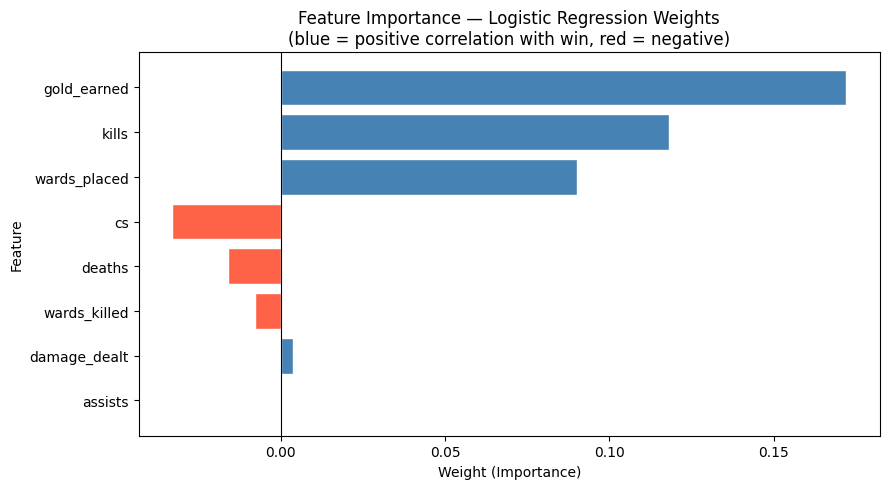


Strongest positive predictor : <StringArray>
['gold_earned']
Length: 1, dtype: str
Strongest negative predictor : <StringArray>
['cs']
Length: 1, dtype: str


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract the weights of the linear layer from the L2 model
weights  = model_l2.linear.weight.data.numpy().flatten()
features = X.columns

# 2. Build a DataFrame sorted by absolute importance (most → least)
feature_importance = pd.DataFrame({
    'Feature'    : features,
    'Importance' : weights
})
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values('Abs_Importance', ascending=True)

print(feature_importance[['Feature', 'Importance']].to_string(index=False))

# 3. Horizontal bar plot for easy reading
colors = ['steelblue' if v >= 0 else 'tomato' for v in feature_importance['Importance']]

plt.figure(figsize=(9, 5))
bars = plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color=colors,
    edgecolor='white'
)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Weight (Importance)')
plt.ylabel('Feature')
plt.title('Feature Importance — Logistic Regression Weights\n'
          '(blue = positive correlation with win, red = negative)')
plt.tight_layout()
plt.show()

# 4. Interpretation hint
top_pos = feature_importance[feature_importance['Importance'] > 0].nlargest(1, 'Importance')['Feature'].values
top_neg = feature_importance[feature_importance['Importance'] < 0].nsmallest(1, 'Importance')['Feature'].values
print(f"\nStrongest positive predictor : {top_pos}")
print(f"Strongest negative predictor : {top_neg}")


---
#### Conclusion

Congratulations on completing the project! You built a logistic regression model to predict League of Legends match outcomes, covering:

- **Step 1** — Data loading, splitting, scaling, and tensor conversion  
- **Step 2** — PyTorch `nn.Module` logistic regression definition  
- **Step 3** — Full training loop with BCE loss and SGD  
- **Step 4** — L2 regularisation via `weight_decay`  
- **Step 5** — Confusion matrix, ROC/AUC curve, and classification report  
- **Step 6** — Model persistence with `torch.save` / `torch.load`  
- **Step 7** — Hyperparameter tuning across learning rates  
- **Step 8** — Feature importance via linear layer weights  

© Copyright IBM Corporation. All rights reserved.
